# 2.1 Unsupervised Machine Learning - Dendogram with Reduced Data

## Table of Contents
### 1. Import Libraries and Data
### 2. Dendograms with Reduced Data
### 3. Insights

## Import Libraries and Data

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [8]:
# Import dataset
path = r'/Users/daxma/OneDrive/Desktop/Data Analytics/Machine Learning with Python/07-25 ClimateWins Analysis/02 Data'
df = pd.read_csv(os.path.join(path, 'Prepared Data', '2020_PCA.csv'))

In [12]:
# Check output
df.head()

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9
0,-12.265105,2.846705,-3.040085,-1.598306,1.021537,-0.464763,2.673393,1.989726,1.582361
1,-11.605655,2.999673,-2.296827,-4.588444,0.230825,-0.746229,2.510591,1.577430,3.193006
2,-12.056563,1.114691,-0.838201,-3.020381,-0.026579,-0.145433,3.471051,2.571364,2.290370
3,-10.065589,0.718798,-0.654489,-2.261898,1.988739,1.405527,1.259309,0.326645,3.133785
4,-7.653545,0.190924,-2.049461,0.329553,2.869812,3.574059,0.061663,3.347828,1.582940


## 2. Dendograms with Reduced Data

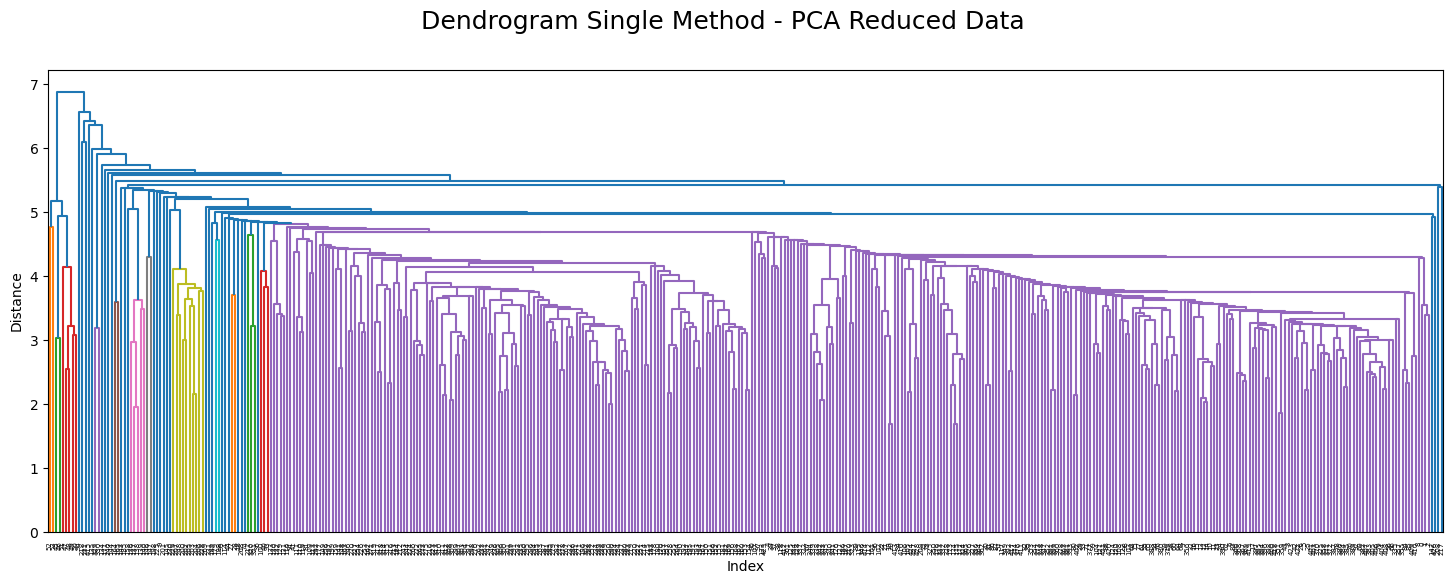

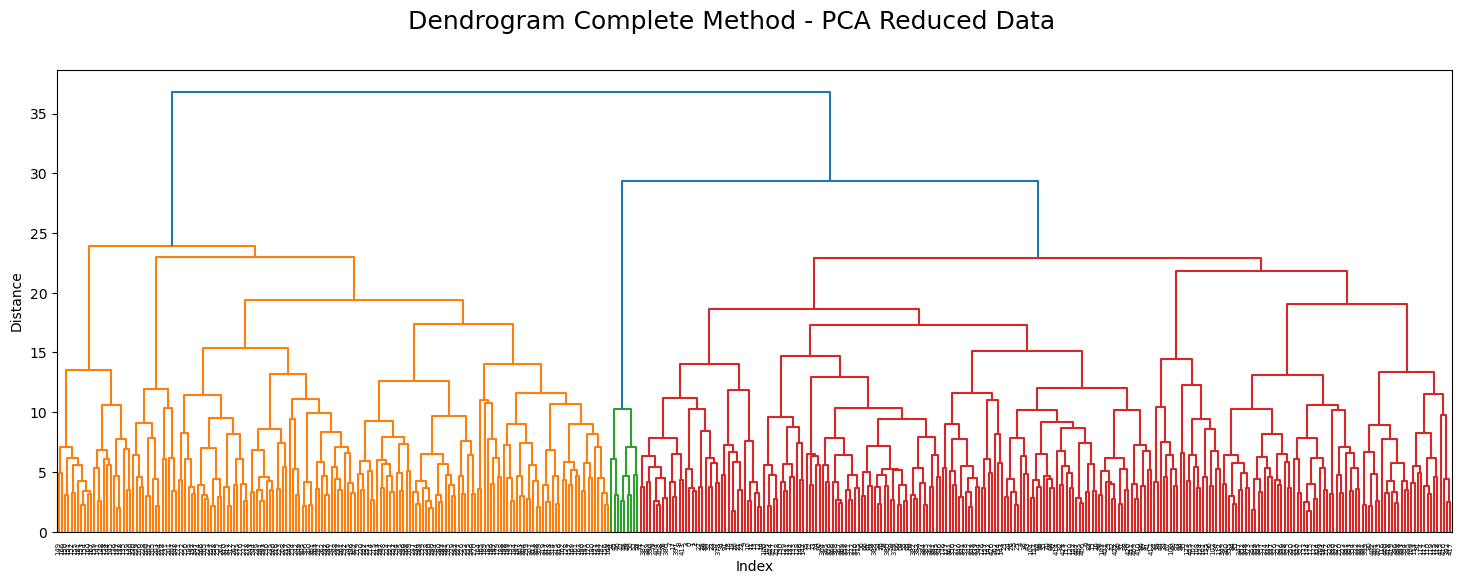

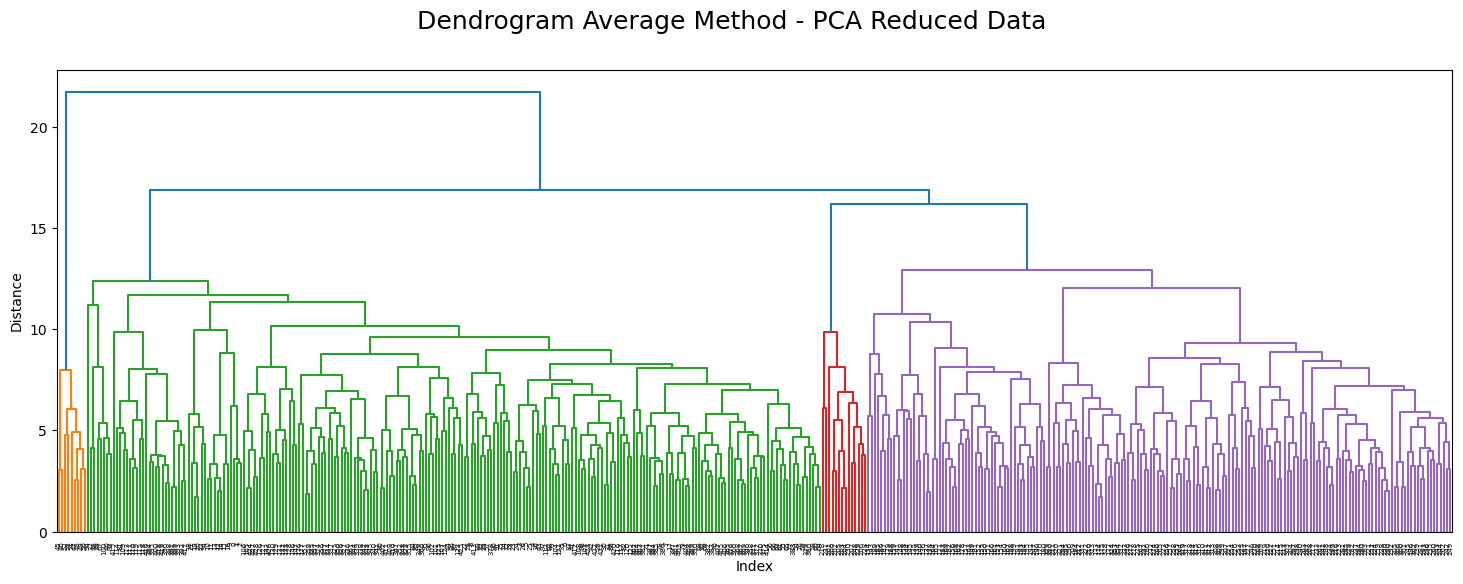

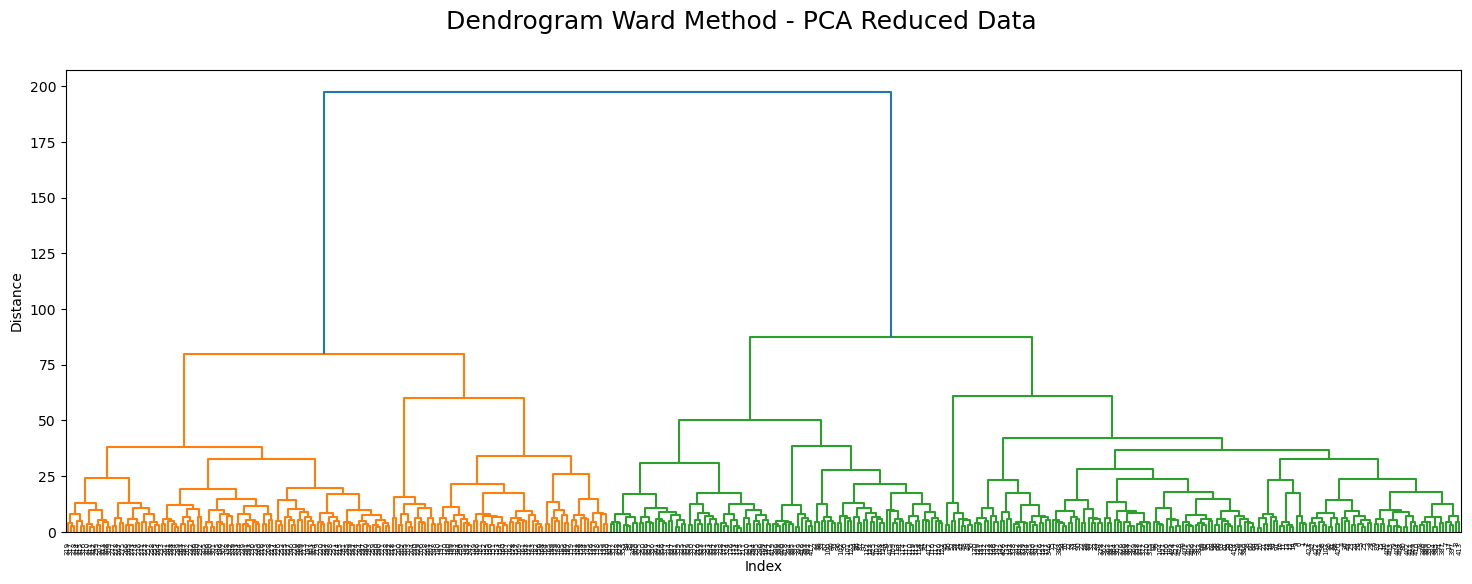

In [16]:
# Run and plot dendrogram for each method
methods = ["single", "complete", "average", "ward"]

for method in methods:
    distance_matrix = linkage(df, method=method)
    plt.figure(figsize=(18,6))
    dendrogram(distance_matrix, leaf_rotation=90)
    plt.xlabel('Index')
    plt.ylabel('Distance')
    plt.suptitle(f"Dendrogram {method.capitalize()} Method - PCA Reduced Data", fontsize=18)
    plt.show()


## 3. Comparative Insights from Dendrogram Analysis – Original vs PCA Reduced Data

**Single Linkage**  
In the original dataset, single linkage showed a strong chaining effect with many gradual merges and only a few distinct boundaries. This indicated continuous variation in daily weather patterns across stations. After PCA reduction, the chaining effect is less pronounced. Clusters form at slightly lower distances and are tighter, suggesting that dimensionality reduction removed noise and redundant variables, allowing more similar days to merge earlier in the process.

**Complete Linkage**  
In the original data, complete linkage revealed three to four main clusters forming at distances around 25 to 40, showing clear but slightly uneven group boundaries. In the PCA reduced data, the main separation occurs at around distance 35 with more balanced cluster sizes. Boundaries between groups are sharper, indicating that PCA retained the most important weather variation features and removed weaker signals that previously blurred cluster edges.

**Average Linkage**  
The original average linkage dendrogram displayed gradual merging with sub patterns visible but not strongly defined. The PCA reduced version shows more structured and evenly spaced clusters. Transitional days between major weather regimes appear better grouped, reflecting PCA’s ability to align the data along principal components that emphasize the largest variance in weather conditions.

**Ward Method**  
In both datasets, Ward linkage produced two dominant clusters at very high distances, reflecting strong seasonal or regional differences such as winter versus summer conditions. In the PCA reduced data, the within cluster cohesion is tighter and the subclusters are more symmetric. This shows that PCA preserved the main drivers of separation while removing less relevant variation, resulting in a cleaner high level split.

**Overall Effect of PCA**  
Across all methods, PCA reduction improved cluster clarity without altering the main high level groupings. The number of dominant clusters remained similar, with seasonal separation still the strongest pattern. However, transitional and mixed weather clusters became more distinct. Single linkage became slightly more interpretable, complete and average linkage showed the greatest improvement in boundary sharpness, and Ward linkage maintained its role in revealing the most significant large scale climatic divisions.
